In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [19]:
# load excel file but use sheet1 only

df = pd.read_excel('main data.xlsx', sheet_name='Sheet1')
df.head()


,jnisAsnaf,TAHUN,DAERAH,jenisSkim,Nama,NoKP,tlahir,Umur,Jantina,kesihatan,...,Ibu Tunggal.1,Pesakit Dialisis (Percuma),Pesakit Dialisis (Berbayar),JumlahPerbelanjaan2,KiraanHK,StatusBaruPemutihan,StatusPermohonanBulanan,StatusDitamatkan,TMulaAgihan,TempohAgihan(Bulan)
0,MISKIN,2024,BL,AGIHAN KEWANGAN MISKIN BULANAN,CHE NAP BINTI IBRAHIM,510322025180,1951-03-22 00:00:00.000,74,P,SAKIT,...,1.0,False,False,240.0,-273.68,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-06-01 00:00:00.000,12
1,MISKIN,2024,BL,AGIHAN KEWANGAN MISKIN BULANAN,AWANG KECHIK BIN OSMAN,640703025497,1964-07-03 00:00:00.000,61,L,SIHAT(NORMAL),...,NaN,False,False,0.0,-393.88,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-04-11 00:00:00.000,12
2,MISKIN,2024,BL,AGIHAN KEWANGAN MISKIN BULANAN,AHMAD NASYAHRUDDIN BIN SAAD,860915265083,1986-09-15 00:00:00.000,39,L,SIHAT(NORMAL),...,NaN,False,False,0.0,-142.79,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-04-08 00:00:00.000,12
3,MISKIN,2024,PT,AGIHAN KEWANGAN MISKIN BULANAN,AMINAH BINTI HUSAIN,560729025380,1956-07-29 00:00:00.000,69,P,SIHAT(NORMAL),...,NaN,False,False,0.0,-133.68,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-04-07 00:00:00.000,12
4,MISKIN,2024,BL,AGIHAN KEWANGAN MISKIN BULANAN,MOHD KARIMI BIN KAMARUDIN,850924025541,1985-09-24 00:00:00.000,40,L,SIHAT(NORMAL),...,NaN,False,False,0.0,-255.59,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-04-05 00:00:00.000,12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9923 entries, 0 to 9922
Data columns (total 90 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   jnisAsnaf                                                              9923 non-null   object 
 1   TAHUN                                                                  9923 non-null   int64  
 2   DAERAH                                                                 9923 non-null   object 
 3   jenisSkim                                                              9923 non-null   object 
 4   Nama                                                                   9923 non-null   object 
 5   NoKP                                                                   9923 non-null   object 
 6   tlahir                                                                 7316 non-null   o

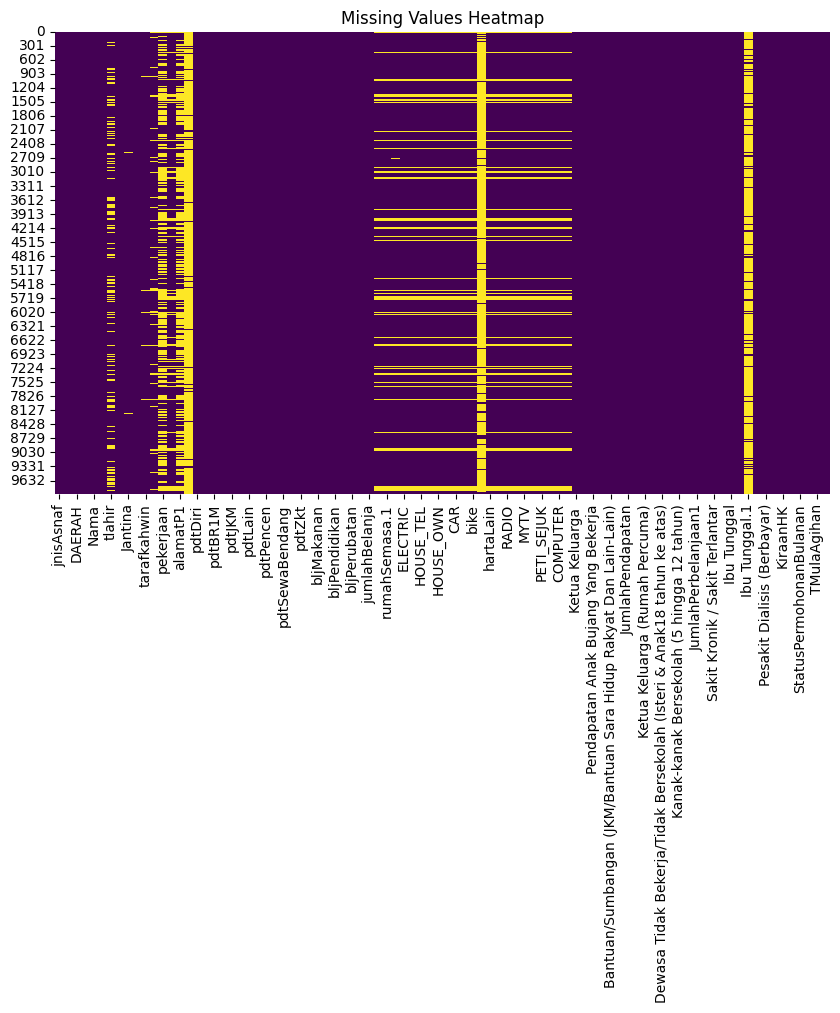

In [22]:
# data information

df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.nunique()
# check for outliers

#missing values

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()



Remaining missing values after handling:
jnisAsnaf                  0
TAHUN                      0
DAERAH                     0
jenisSkim                  0
Nama                       0
                          ..
StatusBaruPemutihan        0
StatusPermohonanBulanan    0
StatusDitamatkan           0
TMulaAgihan                0
TempohAgihan(Bulan)        0
Length: 90, dtype: int64


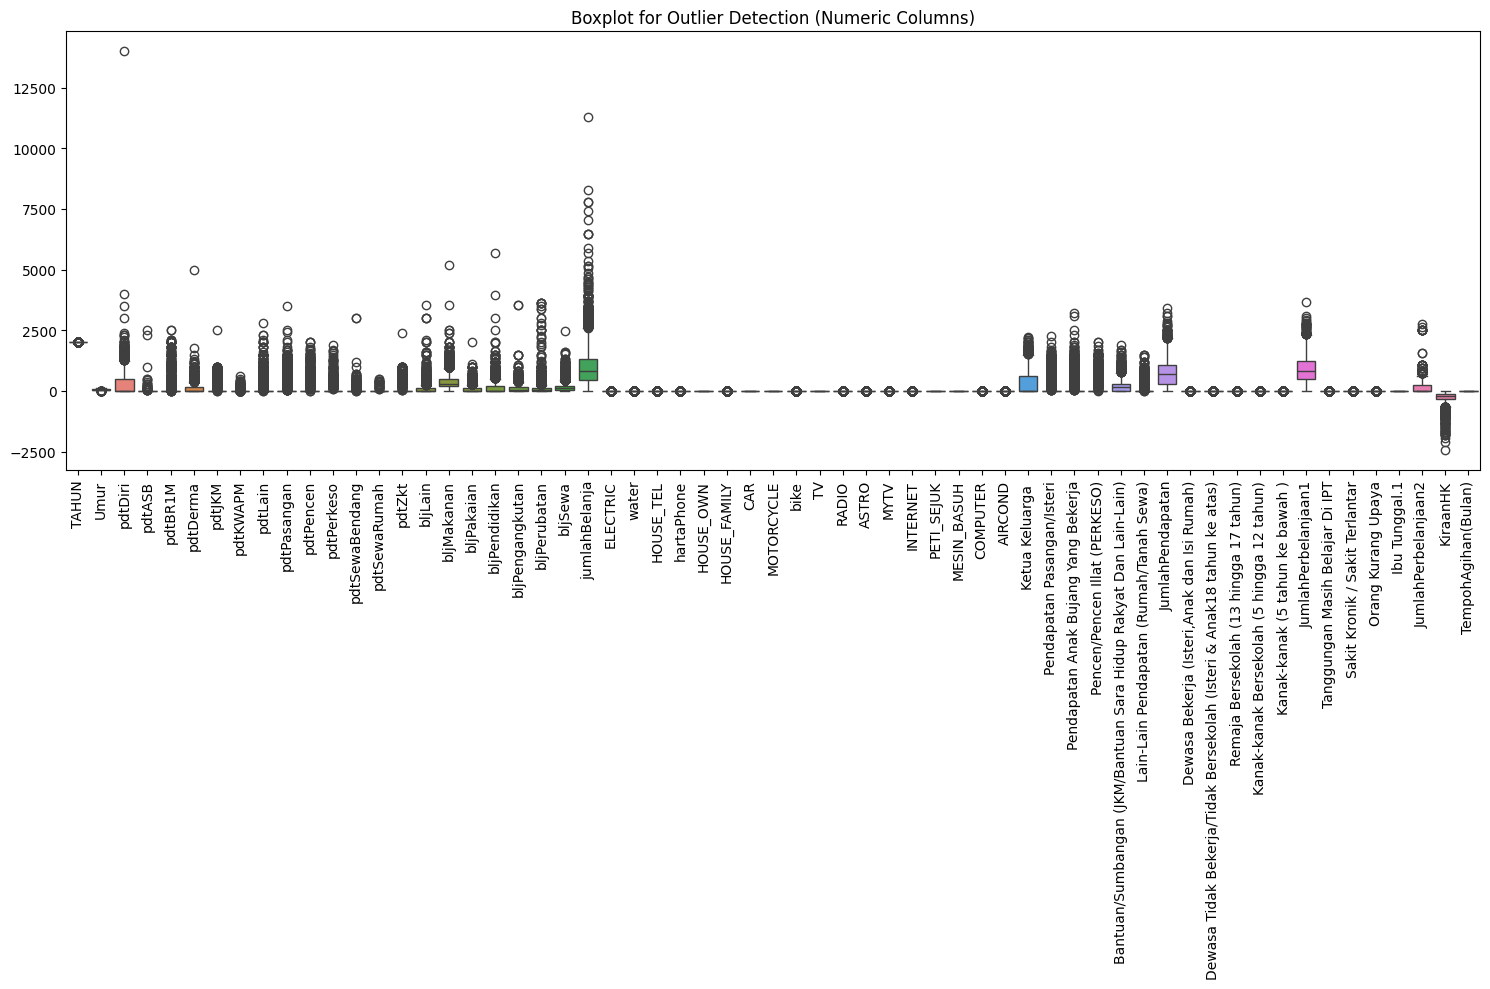

In [25]:
#handle missing values

# For numeric columns, fill with mean
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# For categorical/object columns, fill with mode
categorical_columns = df.select_dtypes(include=['object']).columns
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

print("Remaining missing values after handling:")
print(df.isnull().sum())

# check for outliers in numeric columns only
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numeric_columns])
plt.xticks(rotation=90)
plt.title('Boxplot for Outlier Detection (Numeric Columns)')
plt.tight_layout()
plt.show()

Basic Dataset Information:
Total number of records: 9923
Total number of features: 90

Feature Types Distribution:
float64    50
object     23
int64      11
bool        6
Name: count, dtype: int64


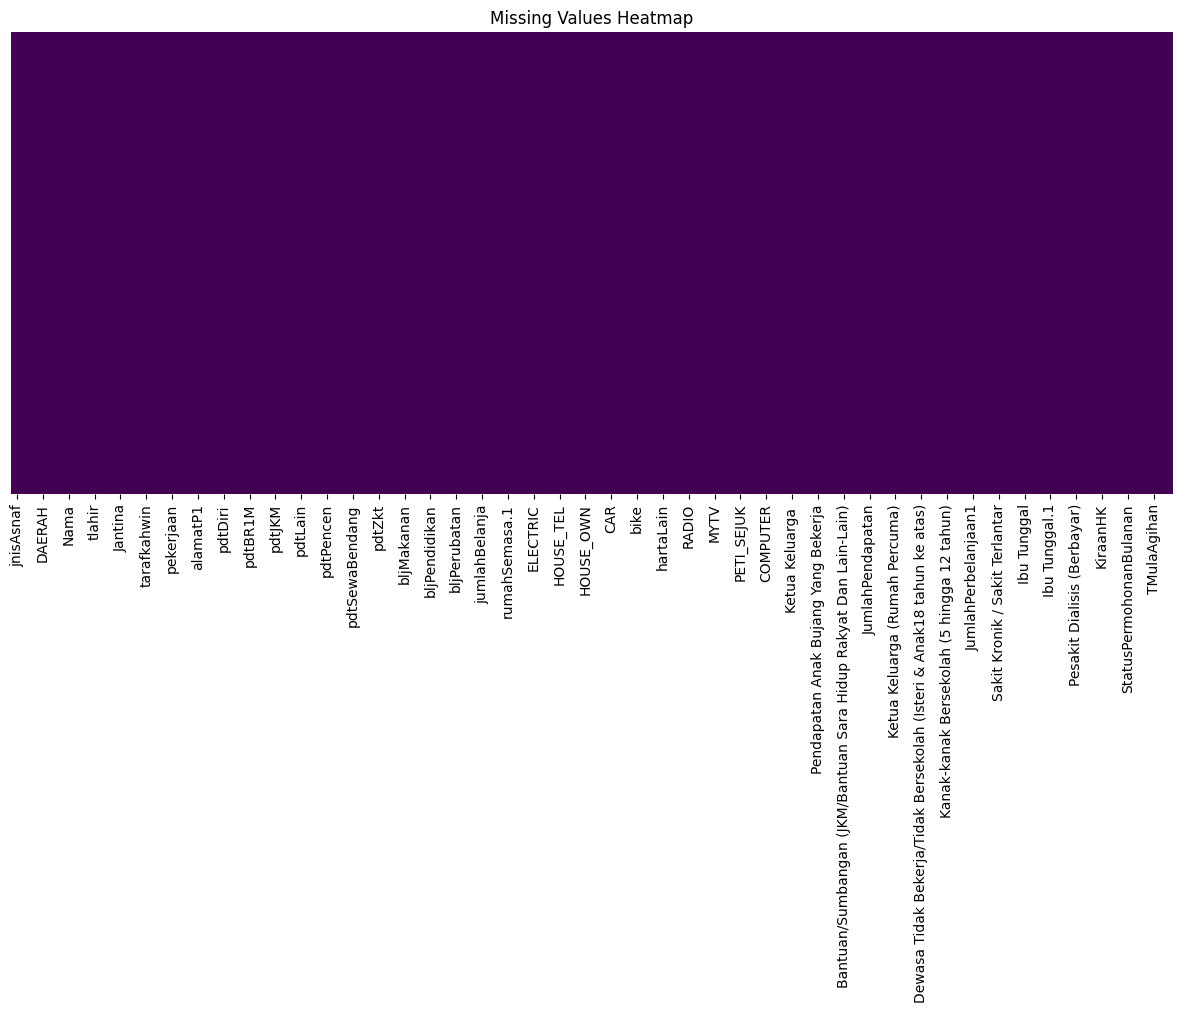

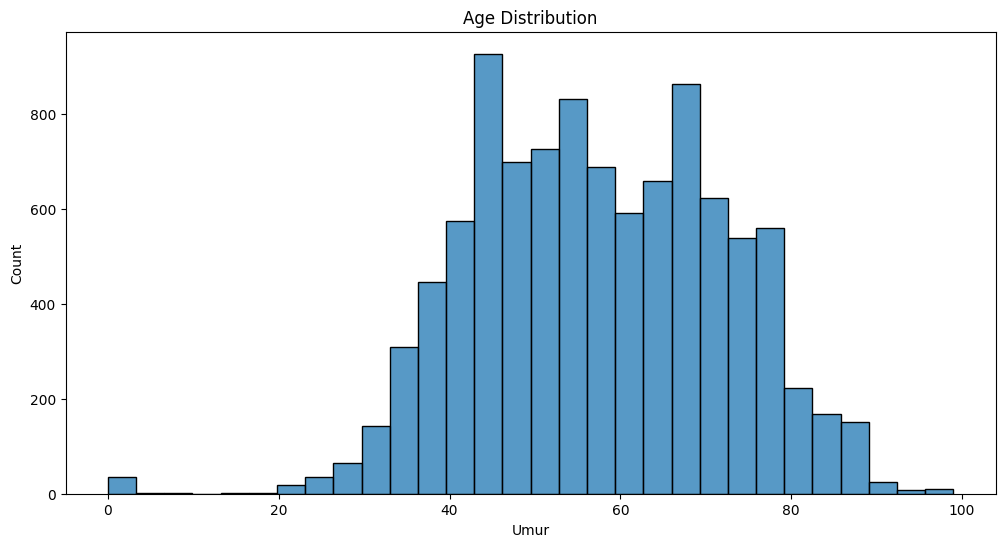

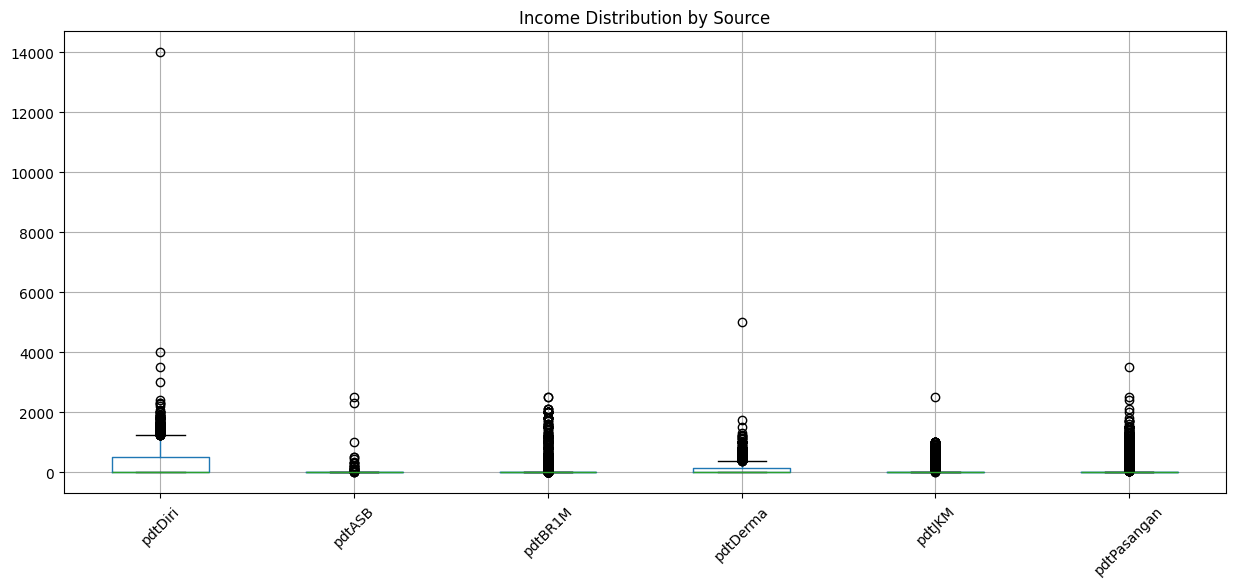

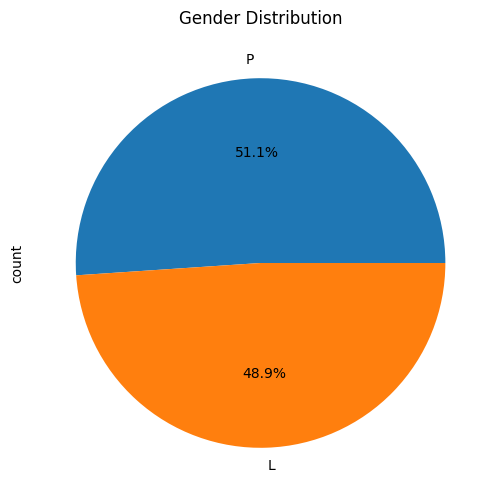

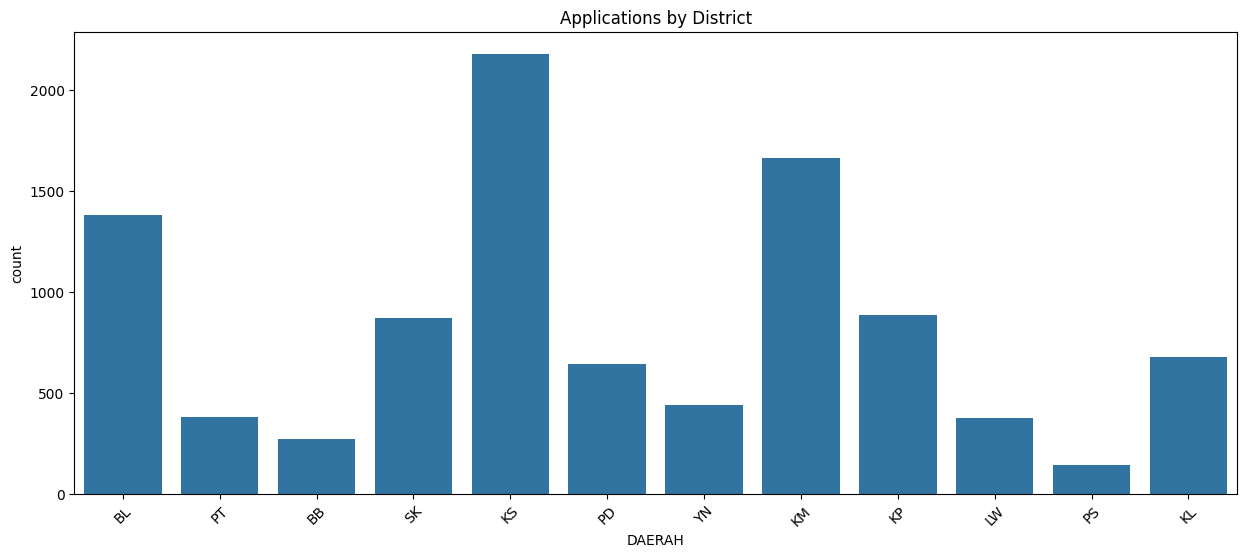

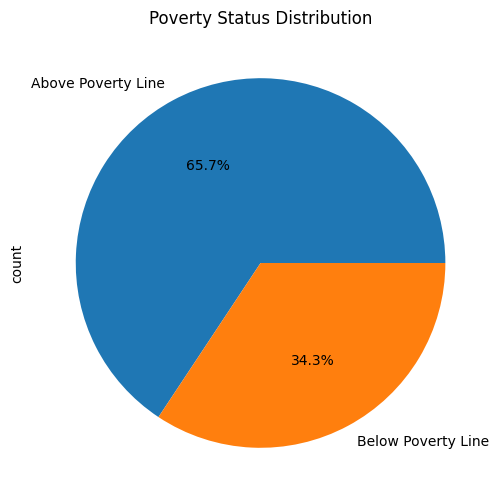

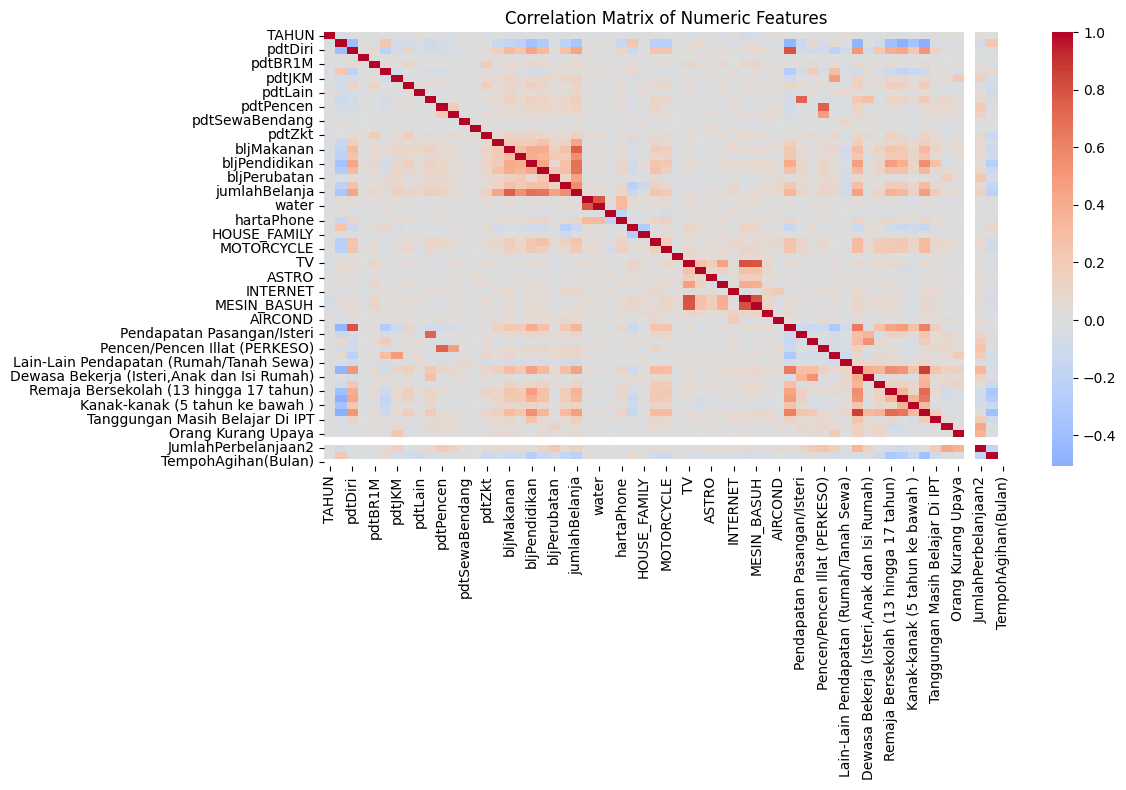

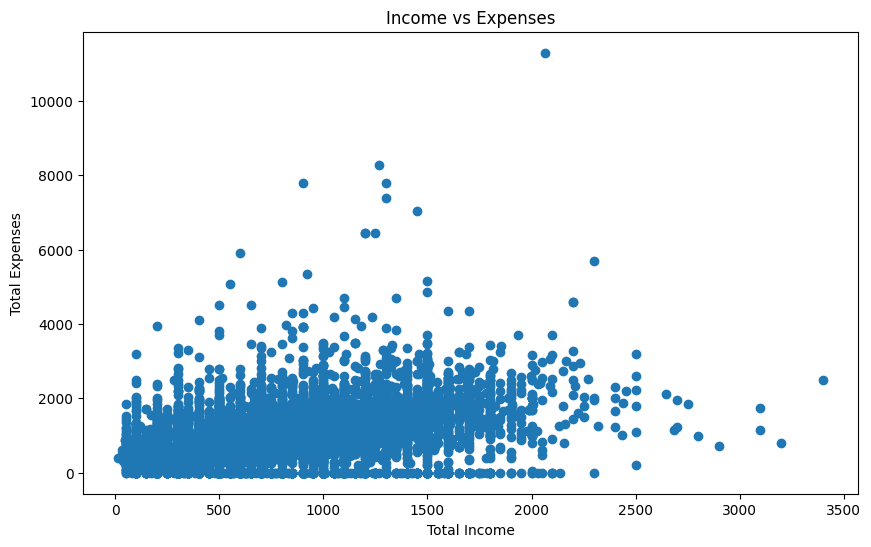

In [26]:
# Exploratory Data Analysis (EDA)

# Basic statistics and information
print("Basic Dataset Information:")
print(f"Total number of records: {len(df)}")
print(f"Total number of features: {len(df.columns)}")
print("\nFeature Types Distribution:")
print(df.dtypes.value_counts())

# Missing values visualization
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Age distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Umur', bins=30)
plt.title('Age Distribution')
plt.show()

# Income analysis
income_cols = ['pdtDiri', 'pdtASB', 'pdtBR1M', 'pdtDerma', 'pdtJKM', 'pdtPasangan']
plt.figure(figsize=(15, 6))
df[income_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Income Distribution by Source')
plt.show()

# Gender distribution
plt.figure(figsize=(8, 6))
df['Jantina'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

# District analysis
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='DAERAH')
plt.xticks(rotation=45)
plt.title('Applications by District')
plt.show()

# Analysis of poverty status
poverty_status = (df['JumlahPendapatan'] < POVERTY_LINE).value_counts()
plt.figure(figsize=(8, 6))
poverty_status.plot(kind='pie', autopct='%1.1f%%', labels=['Above Poverty Line', 'Below Poverty Line'])
plt.title('Poverty Status Distribution')
plt.show()

# Correlation analysis for numeric columns
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix of Numeric Features')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Income vs Expenses
plt.figure(figsize=(10, 6))
plt.scatter(df['JumlahPendapatan'], df['jumlahBelanja'])
plt.xlabel('Total Income')
plt.ylabel('Total Expenses')
plt.title('Income vs Expenses')
plt.show()